# 02 nn.Module 与训练循环

本 Notebook 覆盖：
- `nn.Module` 自定义模型
- 完整训练/验证循环
- TensorBoard 训练可视化

**对应文档**: `docs/02-core/`

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt

device = torch.device(
    'mps'  if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available() else 'cpu'
)
print(f'PyTorch {torch.__version__}，使用设备: {device}')

PyTorch 2.11.0+cpu，使用设备: cpu


## 1. 自定义 Dataset

C:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21452 (\N{CJK UNIFIED IDEOGRAPH-53CC}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 34746 (\N{CJK UNIFIED IDEOGRAPH-87BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26059 (\N{CJK UNIFIED IDEOGRAPH-65CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Adm

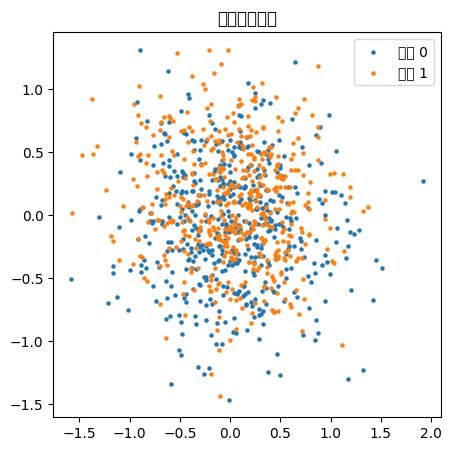

训练集: 800  验证集: 200


In [2]:
class SpiralDataset(Dataset):
    """双螺旋二分类数据集"""
    def __init__(self, n=500, noise=0.3):
        theta = torch.linspace(0, 4 * torch.pi, n)
        r = theta / (4 * torch.pi)
        x1 = torch.stack([r * torch.cos(theta) + noise * torch.randn(n),
                          r * torch.sin(theta) + noise * torch.randn(n)], dim=1)
        x2 = torch.stack([-r * torch.cos(theta) + noise * torch.randn(n),
                          -r * torch.sin(theta) + noise * torch.randn(n)], dim=1)
        self.X = torch.cat([x1, x2], dim=0)
        self.y = torch.cat([torch.zeros(n), torch.ones(n)]).long()

    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


dataset = SpiralDataset(n=500)
train_set, val_set = random_split(dataset, [800, 200], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_set,   batch_size=128, shuffle=False, num_workers=0)

# 可视化数据
fig, ax = plt.subplots(figsize=(5, 5))
X, y = dataset.X, dataset.y
ax.scatter(X[y==0, 0], X[y==0, 1], s=5, label='类别 0')
ax.scatter(X[y==1, 0], X[y==1, 1], s=5, label='类别 1')
ax.set_title('双螺旋数据集')
ax.legend()
plt.show()
print(f'训练集: {len(train_set)}  验证集: {len(val_set)}')

## 2. 定义模型

In [3]:
class MLPClassifier(nn.Module):
    def __init__(self, hidden_dim=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 2),
        )

    def forward(self, x):
        return self.net(x)


model = MLPClassifier().to(device)
print(model)
print(f'参数量: {sum(p.numel() for p in model.parameters()):,}')

MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=2, bias=True)
  )
)
参数量: 33,666


## 3. 训练循环（含 TensorBoard 记录）

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
writer    = SummaryWriter('runs/spiral_mlp')

history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, 51):
    # 训练
    model.train()
    t_loss = 0.0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()
        t_loss += loss.item()
    t_loss /= len(train_loader)

    # 验证
    model.eval()
    v_loss, correct = 0.0, 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            v_loss  += criterion(logits, y).item()
            correct += (logits.argmax(1) == y).sum().item()
    v_loss /= len(val_loader)
    v_acc   = correct / len(val_set)

    # 记录到 TensorBoard
    writer.add_scalars('Loss', {'train': t_loss, 'val': v_loss}, epoch)
    writer.add_scalar('Accuracy/val', v_acc, epoch)

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['val_acc'].append(v_acc)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d} | train_loss={t_loss:.4f} | val_loss={v_loss:.4f} | val_acc={v_acc:.3f}')

writer.close()
print('\nTensorBoard 启动命令: tensorboard --logdir=runs')

Epoch  10 | train_loss=0.6809 | val_loss=0.6799 | val_acc=0.565
Epoch  20 | train_loss=0.6720 | val_loss=0.6816 | val_acc=0.590
Epoch  30 | train_loss=0.6696 | val_loss=0.6895 | val_acc=0.570
Epoch  40 | train_loss=0.6711 | val_loss=0.6825 | val_acc=0.575
Epoch  50 | train_loss=0.6674 | val_loss=0.6893 | val_acc=0.565

TensorBoard 启动命令: tensorboard --logdir=runs


## 4. 可视化训练曲线

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16004\3958344024.py:12: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16004\3958344024.py:12: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16004\3958344024.py:12: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16004\3958344024.py:12: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16004\3958344024.py:12: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_160

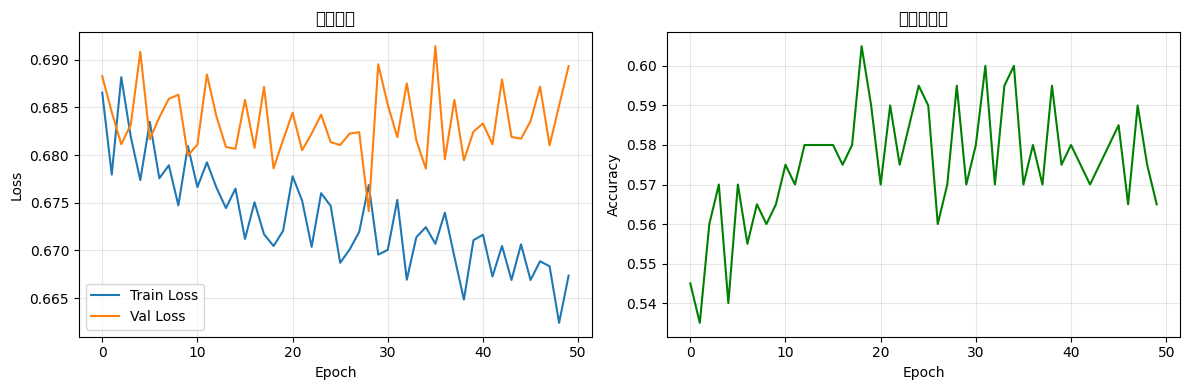

最终验证准确率: 0.565


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train Loss')
ax1.plot(history['val_loss'],   label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('损失曲线'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history['val_acc'], color='green')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('验证准确率'); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'最终验证准确率: {history["val_acc"][-1]:.3f}')

## 5. 决策边界可视化

C:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20915 (\N{CJK UNIFIED IDEOGRAPH-51B3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31574 (\N{CJK UNIFIED IDEOGRAPH-7B56}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 36793 (\N{CJK UNIFIED IDEOGRAPH-8FB9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Administrator\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30028 (\N{CJK UNIFIED IDEOGRAPH-754C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\Adm

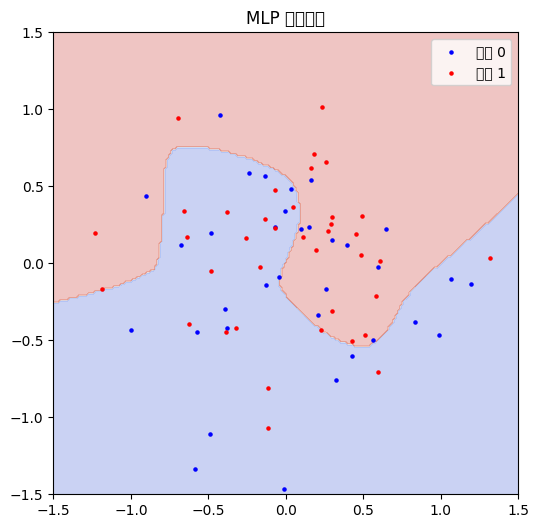

In [6]:
import numpy as np

model.eval()
xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 200), np.linspace(-1.5, 1.5, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32).to(device)

with torch.no_grad():
    Z = model(grid).argmax(1).cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(6, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[y==0, 0], X[y==0, 1], s=5, c='blue',  label='类别 0')
plt.scatter(X[y==1, 0], X[y==1, 1], s=5, c='red',   label='类别 1')
plt.title('MLP 决策边界')
plt.legend()
plt.show()

## 练习题

1. **简单**: 将模型改为只有 1 层隐藏层，观察准确率变化
2. **中等**: 添加学习率调度器 `CosineAnnealingLR`，对比有无调度器的训练曲线
3. **挑战**: 实现带权重衰减的 L2 正则化，并与 PyTorch `weight_decay` 参数对比结果